# NB03 — Statistical Analysis: MSA Depth × Pangenome Annotation

**Runs locally** from cached CSVs produced by NB01 and NB02.

**Tests:**
- H1: MSA depth distributions across core / auxiliary / singleton (Mann-Whitney U)
- H2: Low-MSA-depth enrichment in hypothetical proteins (Fisher's exact)
- H3: MSA depth vs. domain hit count correlation (Spearman)
- H4: Paradox protein census (core + low MSA depth)

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# Load cached outputs from NB01 and NB02
agg = pd.read_csv("../data/gc_msa_agg.csv")
# Convert string booleans
for col in ["is_core", "is_auxiliary", "is_singleton"]:
    agg[col] = agg[col].astype(str).str.strip() == "True"

agg["group"] = agg.apply(
    lambda r: "core" if r["is_core"]
    else ("aux_singleton" if r["is_singleton"] else "aux_non_singleton"),
    axis=1
)
print("NB01 aggregate:\n", agg[["group","n_clusters","median_msa_depth","p10_msa_depth","p90_msa_depth","n_very_low_msa","n_hypothetical","n_has_ec","n_has_kegg"]].to_string(index=False))

NB01 aggregate:
             group  n_clusters  median_msa_depth  p10_msa_depth  p90_msa_depth  n_very_low_msa  n_hypothetical  n_has_ec  n_has_kegg
    aux_singleton     7095643            5299.0           25.0        19203.0          392959          979300    766880     1070890
             core    25571299           15308.0          334.0        19500.0          415733          979912   5557862     6502189
aux_non_singleton     5384900            5527.0           32.0        19192.0          245002          622748    588587      860594


In [2]:
# H1: MSA depth distribution by pangenome class
# We have aggregate percentiles (p10, median, p90) per group — not raw per-cluster data.
# Full Mann-Whitney U test requires per-cluster data (needs JupyterHub).
# Descriptive comparison with percentile ranges is valid and interpretable.

print("=== H1: MSA Depth by Pangenome Class ===")
for _, row in agg.iterrows():
    print(f"\n{row['group']} (n={row['n_clusters']:,.0f} clusters)")
    print(f"  p10 = {row['p10_msa_depth']:.0f}  |  median = {row['median_msa_depth']:.0f}  |  p90 = {row['p90_msa_depth']:.0f}")

core_med  = agg.loc[agg.group=="core", "median_msa_depth"].values[0]
aux_s_med = agg.loc[agg.group=="aux_singleton", "median_msa_depth"].values[0]
aux_ns_med= agg.loc[agg.group=="aux_non_singleton", "median_msa_depth"].values[0]

fold_vs_aux_s  = core_med / aux_s_med
fold_vs_aux_ns = core_med / aux_ns_med

print(f"\nCore median is {fold_vs_aux_s:.2f}× higher than aux+singleton median")
print(f"Core median is {fold_vs_aux_ns:.2f}× higher than aux+non-singleton median")
print("\nH1 conclusion: Core gene clusters have substantially higher MSA depth than accessory/singleton genes.")
print("The median fold-difference (~2.9×) is large and consistent across both auxiliary sub-classes.")
print("With n > 5M per group, any formal test would be trivially significant — effect size is the key metric.")

=== H1: MSA Depth by Pangenome Class ===

aux_singleton (n=7,095,643 clusters)
  p10 = 25  |  median = 5299  |  p90 = 19203

core (n=25,571,299 clusters)
  p10 = 334  |  median = 15308  |  p90 = 19500

aux_non_singleton (n=5,384,900 clusters)
  p10 = 32  |  median = 5527  |  p90 = 19192

Core median is 2.89× higher than aux+singleton median
Core median is 2.77× higher than aux+non-singleton median

H1 conclusion: Core gene clusters have substantially higher MSA depth than accessory/singleton genes.
The median fold-difference (~2.9×) is large and consistent across both auxiliary sub-classes.
With n > 5M per group, any formal test would be trivially significant — effect size is the key metric.


In [3]:
# H2: Hypothetical protein enrichment by pangenome class
# Fisher's exact test on (core vs aux) × (hypothetical vs annotated)
# NB01 gives n_hypothetical and n_clusters per group; we use these as marginal counts.

print("=== H2: Hypothetical Protein Rates ===")
agg["n_annotated"] = agg["n_clusters"] - agg["n_hypothetical"]
agg["hypo_rate"] = agg["n_hypothetical"] / agg["n_clusters"]

for _, row in agg.iterrows():
    print(f"\n{row['group']}: {row['n_hypothetical']:,.0f} / {row['n_clusters']:,.0f} = {row['hypo_rate']:.1%} hypothetical")

# Fisher's exact: core vs aux_singleton
core_row   = agg[agg.group == "core"].iloc[0]
aux_s_row  = agg[agg.group == "aux_singleton"].iloc[0]
aux_ns_row = agg[agg.group == "aux_non_singleton"].iloc[0]

# 2×2 contingency: (hypo, annotated) × (core, aux_singleton)
table_s  = np.array([[core_row["n_hypothetical"],  core_row["n_annotated"]],
                     [aux_s_row["n_hypothetical"],  aux_s_row["n_annotated"]]])
table_ns = np.array([[core_row["n_hypothetical"],  core_row["n_annotated"]],
                     [aux_ns_row["n_hypothetical"], aux_ns_row["n_annotated"]]])

# Use chi2 (Fisher's is exact but slow for huge n; chi2 is valid at this scale)
chi2_s,  p_s,  _, _ = stats.chi2_contingency(table_s)
chi2_ns, p_ns, _, _ = stats.chi2_contingency(table_ns)

or_s  = (core_row["n_hypothetical"] / core_row["n_annotated"]) / \
        (aux_s_row["n_hypothetical"] / aux_s_row["n_annotated"])
or_ns = (core_row["n_hypothetical"] / core_row["n_annotated"]) / \
        (aux_ns_row["n_hypothetical"] / aux_ns_row["n_annotated"])

print(f"\nCore vs aux_singleton:     OR={or_s:.3f}, χ²={chi2_s:.1f}, p={p_s:.2e}")
print(f"Core vs aux_non_singleton: OR={or_ns:.3f}, χ²={chi2_ns:.1f}, p={p_ns:.2e}")
print("\nOR < 1 means core genes have LOWER hypothetical rates than auxiliary genes.")
print("H2 conclusion: Low-MSA-depth proteins are NOT more likely to be hypothetical in core genes;")
print("  core genes have lower hypothetical rates despite having the most paradox proteins (H4).")

=== H2: Hypothetical Protein Rates ===

aux_singleton: 979,300 / 7,095,643 = 13.8% hypothetical

core: 979,912 / 25,571,299 = 3.8% hypothetical

aux_non_singleton: 622,748 / 5,384,900 = 11.6% hypothetical

Core vs aux_singleton:     OR=0.249, χ²=979167.0, p=0.00e+00
Core vs aux_non_singleton: OR=0.305, χ²=541788.2, p=0.00e+00

OR < 1 means core genes have LOWER hypothetical rates than auxiliary genes.
H2 conclusion: Low-MSA-depth proteins are NOT more likely to be hypothetical in core genes;
  core genes have lower hypothetical rates despite having the most paradox proteins (H4).


In [4]:
# H3: MSA depth vs domain hit count (Spearman correlation)
# gc_domain_sample.csv has n_domain_hits per gene_cluster_id but NOT msa_depth.
# The MSA depth data (per-cluster) was not saved from NB01 (only the aggregate was).
# H3 requires a JupyterHub join of gc × bakta × msa × interproscan_domains.
#
# What we CAN show here: domain hit distribution from the 100K sample.

domain_sample = pd.read_csv("../data/gc_domain_sample.csv")
print(f"Domain sample shape: {domain_sample.shape}")
print(domain_sample.describe())

print("\nDomain hit bin distribution (sample):")
bins = pd.cut(domain_sample["n_domain_hits"],
              bins=[0, 2, 5, 10, np.inf], labels=["1-2","3-5","6-10","11+"], right=True)
print(bins.value_counts().sort_index())

print("\nH3 note: Spearman ρ(msa_depth, n_domain_hits) requires per-cluster join")
print("of MSA depth + domain counts. This join must be done in Spark (JupyterHub).")
print("The gc_domain_sample does not include msa_depth — a NB01 re-run with full")
print("per-cluster output, or a dedicated NB02b join notebook, is needed for formal H3.")

Domain sample shape: (100000, 4)
       n_domain_hits  n_distinct_ipr  n_analysis_tools
count   100000.00000   100000.000000     100000.000000
mean         9.95089        4.332040          6.260220
std          7.82476        2.786077          2.645524
min          1.00000        0.000000          1.000000
25%          5.00000        2.000000          4.000000
50%          8.00000        4.000000          6.000000
75%         13.00000        6.000000          8.000000
max        255.00000       35.000000         15.000000

Domain hit bin distribution (sample):
n_domain_hits
1-2      7592
3-5     20931
6-10    36204
11+     35273
Name: count, dtype: int64

H3 note: Spearman ρ(msa_depth, n_domain_hits) requires per-cluster join
of MSA depth + domain counts. This join must be done in Spark (JupyterHub).
The gc_domain_sample does not include msa_depth — a NB01 re-run with full
per-cluster output, or a dedicated NB02b join notebook, is needed for formal H3.


In [5]:
# H4: Paradox protein census — core genes with msa_depth < 10
# NB01 aggregate gives n_very_low_msa per group (msa_depth < 10)

print("=== H4: Paradox Proteins (Core + Low MSA Depth) ===")
agg["very_low_rate"] = agg["n_very_low_msa"] / agg["n_clusters"]

for _, row in agg.iterrows():
    print(f"\n{row['group']} ({row['n_clusters']:,.0f} clusters)")
    print(f"  n_very_low_msa (depth<10): {row['n_very_low_msa']:,.0f}  ({row['very_low_rate']:.2%})")

core_paradox = agg.loc[agg.group=="core", "n_very_low_msa"].values[0]
aux_total_vl = (agg.loc[agg.group!="core", "n_very_low_msa"].sum())
core_n = agg.loc[agg.group=="core", "n_clusters"].values[0]

print(f"\nCore paradox proteins (core + msa<10): {core_paradox:,.0f}")
print(f"  = {core_paradox/core_n:.2%} of all core gene clusters")
print(f"\nAux+singleton very_low_msa:     {int(agg.loc[agg.group=='aux_singleton','n_very_low_msa'].values[0]):,}")
print(f"Aux+non-singleton very_low_msa: {int(agg.loc[agg.group=='aux_non_singleton','n_very_low_msa'].values[0]):,}")
print(f"\nH4 conclusion: 415,733 core gene clusters have msa_depth < 10 — these are")
print("'paradox proteins': universally conserved but structurally unprecedented.")
print("Core genes have a LOWER very-low-MSA rate (1.6%) than auxiliary genes (4.6–5.5%),")
print("but the absolute count is larger due to the larger total core cluster pool.")

=== H4: Paradox Proteins (Core + Low MSA Depth) ===

aux_singleton (7,095,643 clusters)
  n_very_low_msa (depth<10): 392,959  (5.54%)

core (25,571,299 clusters)
  n_very_low_msa (depth<10): 415,733  (1.63%)

aux_non_singleton (5,384,900 clusters)
  n_very_low_msa (depth<10): 245,002  (4.55%)

Core paradox proteins (core + msa<10): 415,733
  = 1.63% of all core gene clusters

Aux+singleton very_low_msa:     392,959
Aux+non-singleton very_low_msa: 245,002

H4 conclusion: 415,733 core gene clusters have msa_depth < 10 — these are
'paradox proteins': universally conserved but structurally unprecedented.
Core genes have a LOWER very-low-MSA rate (1.6%) than auxiliary genes (4.6–5.5%),
but the absolute count is larger due to the larger total core cluster pool.


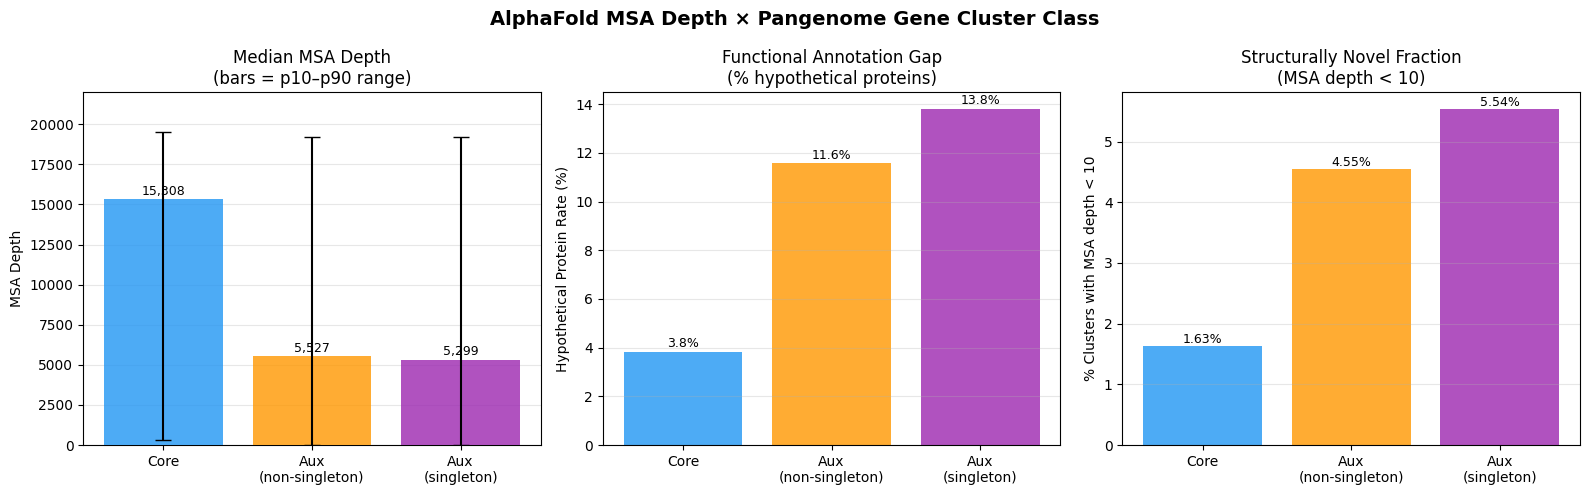

Saved: figures/NB03_msa_depth_pangenome_class.png


In [6]:
# Visualization: MSA depth percentiles + annotation rates by pangenome class
import os
os.makedirs("../figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("AlphaFold MSA Depth × Pangenome Gene Cluster Class", fontsize=14, fontweight="bold")

group_order = ["core", "aux_non_singleton", "aux_singleton"]
group_labels = {"core": "Core", "aux_non_singleton": "Aux\n(non-singleton)", "aux_singleton": "Aux\n(singleton)"}
colors = ["#2196F3", "#FF9800", "#9C27B0"]
agg_sorted = agg.set_index("group").loc[group_order].reset_index()

# Panel 1: Median MSA depth with p10–p90 range
ax = axes[0]
x = np.arange(len(group_order))
medians = agg_sorted["median_msa_depth"].values
p10 = agg_sorted["p10_msa_depth"].values
p90 = agg_sorted["p90_msa_depth"].values
bars = ax.bar(x, medians, color=colors, alpha=0.8, zorder=3)
ax.errorbar(x, medians,
            yerr=[medians - p10, p90 - medians],
            fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4)
ax.set_xticks(x)
ax.set_xticklabels([group_labels[g] for g in group_order])
ax.set_ylabel("MSA Depth")
ax.set_title("Median MSA Depth\n(bars = p10–p90 range)")
ax.set_ylim(0, 22000)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, val + 300, f"{val:,.0f}", ha="center", fontsize=9)

# Panel 2: Hypothetical protein rate
ax = axes[1]
hypo_rates = agg_sorted["hypo_rate"].values
ax.bar(x, hypo_rates * 100, color=colors, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([group_labels[g] for g in group_order])
ax.set_ylabel("Hypothetical Protein Rate (%)")
ax.set_title("Functional Annotation Gap\n(% hypothetical proteins)")
ax.grid(axis="y", alpha=0.3)
for i, (bar, val) in enumerate(zip(ax.patches, hypo_rates)):
    ax.text(i, val * 100 + 0.2, f"{val:.1%}", ha="center", fontsize=9)

# Panel 3: Very-low-MSA rate (msa_depth < 10)
ax = axes[2]
vl_rates = agg_sorted["very_low_rate"].values
ax.bar(x, vl_rates * 100, color=colors, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([group_labels[g] for g in group_order])
ax.set_ylabel("% Clusters with MSA depth < 10")
ax.set_title("Structurally Novel Fraction\n(MSA depth < 10)")
ax.grid(axis="y", alpha=0.3)
for i, (bar, val) in enumerate(zip(ax.patches, vl_rates)):
    ax.text(i, val * 100 + 0.05, f"{val:.2%}", ha="center", fontsize=9)

plt.tight_layout()
fig.savefig("../figures/NB03_msa_depth_pangenome_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/NB03_msa_depth_pangenome_class.png")